In [1]:
import streamlit as st
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import cv2
from facenet_pytorch import MTCNN, InceptionResnetV1
from PIL import Image
import PIL
import numpy as np
from typing import Tuple, List, Optional, Dict
import io
import os
import warnings
import json
from datetime import datetime
import base64
import shutil
from IPython.display import clear_output, Image, display

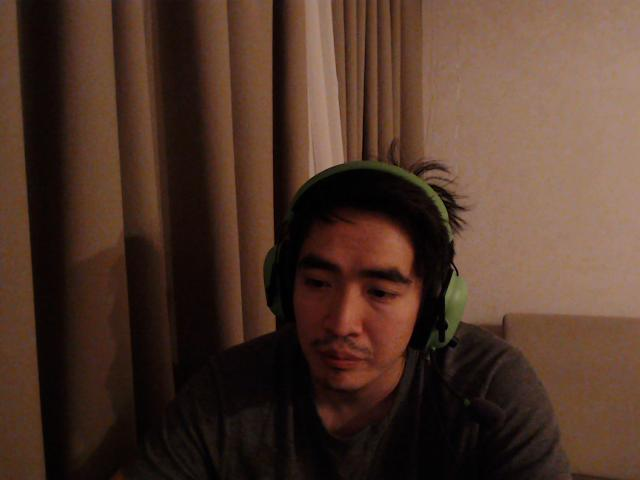

error: OpenCV(4.10.0) /io/opencv/modules/highgui/src/window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'


In [2]:
cap = cv2.VideoCapture(0)
try:
    while True:
        # Capture frame-by-frame
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break
        
        # Convert BGR to RGB (since OpenCV uses BGR by default)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Convert to PIL Image
        pil_img = PIL.Image.fromarray(frame_rgb)
        
        # Convert PIL image to bytes
        buf = io.BytesIO()
        pil_img.save(buf, format='JPEG')
        buf.seek(0)
        
        # Clear previous output and display new frame
        clear_output(wait=True)
        display(Image(data=buf.read()))
        
finally:
    # When everything is done, release the capture
    cap.release()
    cv2.destroyAllWindows()

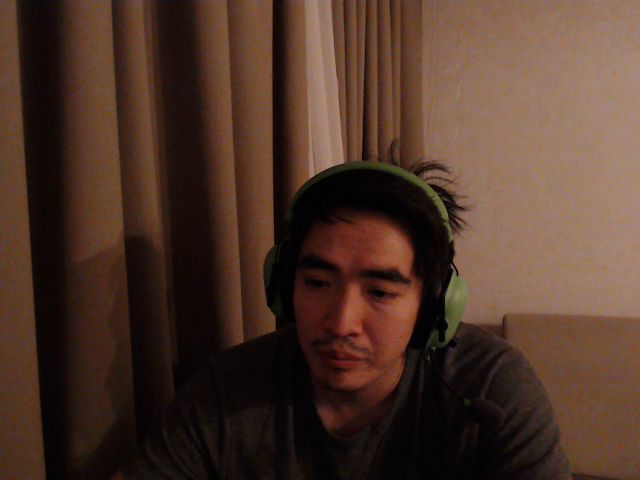

In [9]:
pil_img

In [4]:
device='cuda'

model = InceptionResnetV1(pretrained='vggface2',
                          device=device).eval()
mtcnn = MTCNN(keep_all=False,
              device=device,
              post_process=False, image_size=225)
# # For a model pretrained on CASIA-Webface
# model = InceptionResnetV1(pretrained='casia-webface').eval()

# # For an untrained model with 100 classes
# model = InceptionResnetV1(num_classes=100).eval()

# # For an untrained 1001-class classifier
# model = InceptionResnetV1(classify=True, num_classes=1001).eval()

/home/beybars/Desktop/beybars/projects/side_hustle/EKTU/venv/lib/python3.12/site-packages/facenet_pytorch/models/inception_resnet_v1.py:329: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experiment

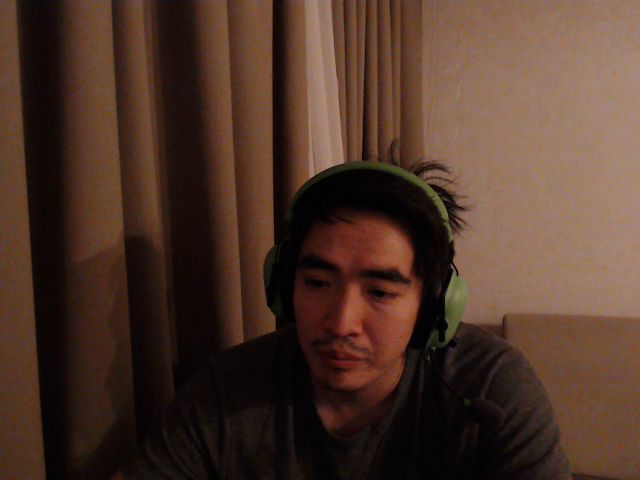

In [10]:
pil_img

In [5]:
mtcnn.detect(pil_img)

(array([[280.95159912109375, 207.75546264648438, 417.95953369140625,
         393.85736083984375]], dtype=object),
 array([0.9999979734420776], dtype=object))

In [8]:
pil_img.size

(640, 480)

In [19]:
out_detector = mtcnn(pil_img).to(device)

In [20]:
res_1 = model(out_detector.unsqueeze(0))

In [21]:
res_2 = model(out_detector.unsqueeze(0))

In [22]:
res_3 = model(out_detector.unsqueeze(0))

In [23]:
res_2@res_1.T

tensor([[1.]], device='cuda:0', grad_fn=<MmBackward0>)

In [24]:
res_2@res_3.T

tensor([[1.]], device='cuda:0', grad_fn=<MmBackward0>)

In [25]:
res_1@res_3.T

tensor([[1.]], device='cuda:0', grad_fn=<MmBackward0>)

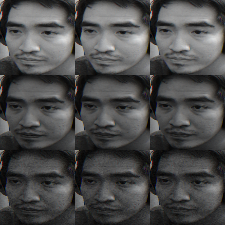

In [27]:
PIL.Image.fromarray(mtcnn(frame_rgb).numpy().reshape(225, 225, 3).astype(np.uint8))

In [3]:
from ultralytics import YOLO

model = YOLO('./V2_best.pt')

TypeError: ERROR ❌️ ./V2_best.pt appears to be an Ultralytics YOLOv5 model originally trained with https://github.com/ultralytics/yolov5.
This model is NOT forwards compatible with YOLOv8 at https://github.com/ultralytics/ultralytics.
Recommend fixes are to train a new model using the latest 'ultralytics' package or to run a command with an official Ultralytics model, i.e. 'yolo predict model=yolov8n.pt'

In [ ]:
import os
os.environ['ROBOFLOW_API_KEY'] = 'Twdup3qP8sok8DPVIx0T'

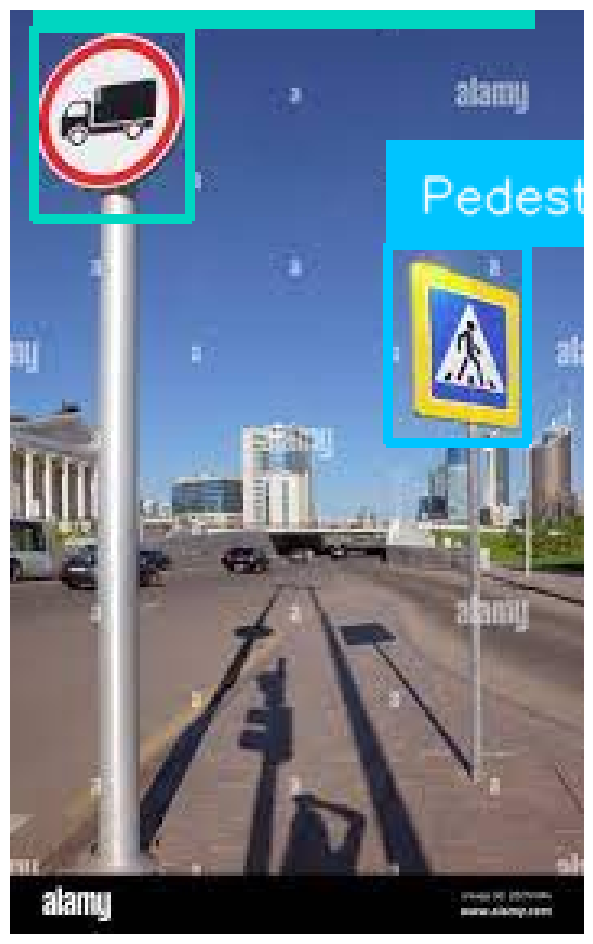

In [27]:
from inference import get_model
import supervision as sv
import cv2

# define the image url to use for inference
image_file = "./images (1).jpeg"
image = cv2.imread(image_file)

# load a pre-trained yolov8n model
#model = get_model(model_id="traffic_sign-gv5rp-t0k2e-q8meh/1")
model = get_model(model_id="traffic_sign-gv5rp-zklpc/1")

# run inference on our chosen image, image can be a url, a numpy array, a PIL image, etc.
results = model.infer(image)[0]

# load the results into the supervision Detections api
detections = sv.Detections.from_inference(results)

# create supervision annotators
bounding_box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

# annotate the image with our inference results
annotated_image = bounding_box_annotator.annotate(
    scene=image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections)

# display the image
sv.plot_image(annotated_image)

In [32]:
model.class_names

['Barrier Ahead',
 'Cycle Crossing',
 'Give Way',
 'Horn Prohibited',
 'Hospital',
 'Left Hair Pin Bend',
 'Left hand curve',
 'Men at Work',
 'No Parking',
 'No Stopping',
 'Parking Lot Cars',
 'Parking Lot Cycle',
 'Pedestrian Crossing',
 'Pedestrian Prohibited',
 'Petrol Pump- Gas Station',
 'Right Hair Pin Bend',
 'Right Hand Curve',
 'Right Reverse Bend',
 'Road Wideness Ahead',
 'School Ahead',
 'Speed Limit -10-',
 'Speed Limit -100-',
 'Speed Limit -35-',
 'Speed Limit -60-',
 'Speed Limit -80-',
 'Speed limit -40-',
 'Stop',
 'Straight Prohibitor No Entry']

In [24]:
results.predictions

[ObjectDetectionPrediction(x=126.0, y=103.5, width=242.0, height=201.0, confidence=0.46531951427459717, class_name='Men at Work', class_confidence=None, class_id=7, tracker_id=None, detection_id='513a300b-9d63-49e1-8226-7dc18a3b4f03', parent_id=None)]

In [11]:
results

ObjectDetectionInferenceResponse(visualization=None, inference_id=None, frame_id=None, time=None, image=InferenceResponseImage(width=1280, height=720), predictions=[ObjectDetectionPrediction(x=126.0, y=103.5, width=242.0, height=201.0, confidence=0.4653691053390503, class_name='Men at Work', class_confidence=None, class_id=7, tracker_id=None, detection_id='47aaaa8b-7b99-4ad6-a2eb-1c18ba9a3b87', parent_id=None)])